In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import joblib

In [2]:
df=pd.read_csv(
    "../data/processed/hyderabad_cleaned.csv"
)

In [3]:
median_price=df['price'].median()

In [4]:
df['premium']=(
    df['price']>median_price
).astype(int)

In [5]:
df['premium'].value_counts()

premium
0    1138
1    1138
Name: count, dtype: int64

In [6]:
X=df.drop(
    columns=['price','premium']
)
y=df['premium']

In [7]:
numerical_features=X.select_dtypes(
    include=np.number
).columns.tolist()
categorical_features=X.select_dtypes(
    exclude=np.number
).columns.tolist()

In [8]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [9]:
numerical_transformer=Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'scaler',
        StandardScaler()
    )
])

In [10]:
categorical_transformer=Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='most_frequent')
    ),
    (
        'encoder',
        OneHotEncoder(
            handle_unknown='ignore'
        )
    )
])

In [16]:
preprocessor=ColumnTransformer([
    (
        'num',
        
        numerical_transformer,
        numerical_features
    ),
    (
        'cat',
        
        categorical_transformer,
        categorical_features
    )
])

In [17]:
clf_pipeline=Pipeline([
    (
        'preprocessor',
        preprocessor
    ),
    (
        'model',
        RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [18]:
clf_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [20]:
y_pred=clf_pipeline.predict(X_test)

In [21]:
y_probs=clf_pipeline.predict_proba(X_test)[:,1]

In [22]:
accuracy=accuracy_score(
    y_test,
    y_pred
)
precision=precision_score(
    y_test,
    y_pred
)
recall=recall_score(
    y_test,
    y_pred
)
f1=f1_score(
    y_test,
    y_pred
)

In [23]:
metrics_df=pd.DataFrame({
    'Metric':[
        'Accuracy',
        "Precision",
        "Recall",
        "f1_score"
    ],
    "Value":[
        accuracy,
        precision,
        recall,
        f1
    ]
}
)
metrics_df

,Metric,Value
0,Accuracy,0.993421
1,Precision,0.987013
2,Recall,1.000000
3,f1_score,0.993464


In [24]:
metrics_df.to_csv(
    "../reports/classification_metrics.csv",
    index=False
)

In [26]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       228
           1       0.99      1.00      0.99       228

    accuracy                           0.99       456
   macro avg       0.99      0.99      0.99       456
weighted avg       0.99      0.99      0.99       456



In [27]:
cm=confusion_matrix(y_test,y_pred)

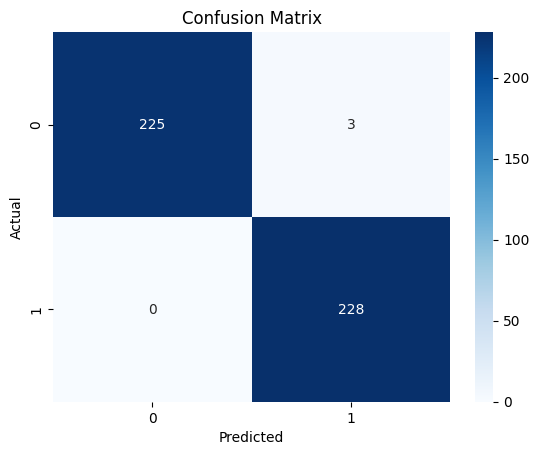

In [28]:
plt.Figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig(
    "../images/confusion_matrix.png",
    bbox_inches='tight'
)
plt.show()

In [29]:
fpr,tpr,thresholds=roc_curve(y_test,y_probs)

In [32]:
roc_auc=auc(fpr,tpr)

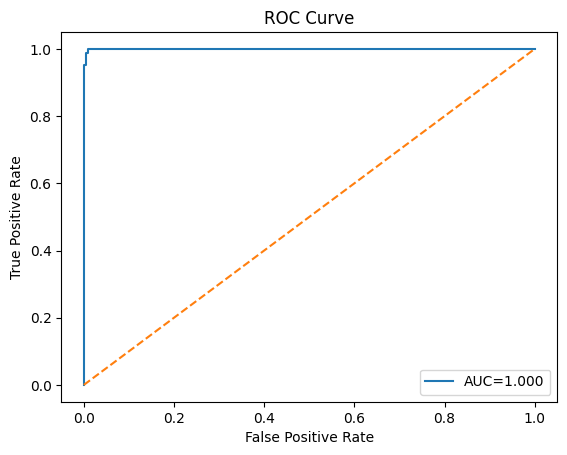

In [38]:
plt.Figure(figsize=(8,5))
plt.plot(
    fpr,
    tpr,
    label=f"AUC={roc_auc:.3f}"
)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig(
    "../images/roc_curve.png",
    bbox_inches='tight'

)
plt.show()

In [39]:
precision_vals,recall_vals,pr_thresholds=precision_recall_curve(
    y_test,
    y_probs
)

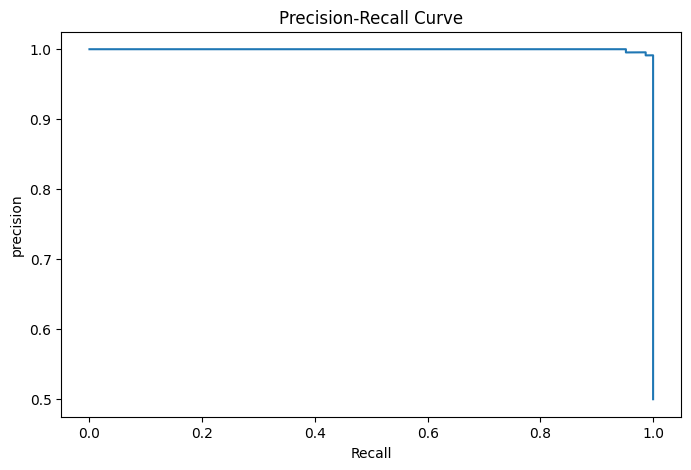

In [41]:
plt.figure(figsize=(8,5))
plt.plot(
    recall_vals,
    precision_vals
)
plt.xlabel("Recall")
plt.ylabel("precision")
plt.title("Precision-Recall Curve")

plt.savefig(
    "../images/pr_curve.png",
    bbox_inches="tight"
)

In [42]:
thresholds=[0.3,0.5,0.7]

In [43]:
for threshold in thresholds:
    preds=(
        y_probs>=threshold
    ).astype(int)
    cm=confusion_matrix(
        y_test,
        preds
    )
    print('\n Threshold:',threshold)
    print(cm)
    print(classification_report(
        y_test,
        preds
    ))


 Threshold: 0.3
[[218  10]
 [  0 228]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       228
           1       0.96      1.00      0.98       228

    accuracy                           0.98       456
   macro avg       0.98      0.98      0.98       456
weighted avg       0.98      0.98      0.98       456


 Threshold: 0.5
[[225   3]
 [  0 228]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       228
           1       0.99      1.00      0.99       228

    accuracy                           0.99       456
   macro avg       0.99      0.99      0.99       456
weighted avg       0.99      0.99      0.99       456


 Threshold: 0.7
[[227   1]
 [  7 221]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       228
           1       1.00      0.97      0.98       228

    accuracy                           0.98       456
   macro

In [44]:
skf=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [45]:
cv_scores=cross_val_score(
    clf_pipeline,
    X,
    y,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)

In [46]:
print(f'''CV ROC AUC Scores:
{cv_scores}
Mean ROC AUC :
{cv_scores.mean()}''')

CV ROC AUC Scores:
[0.99986534 1.         0.99992271 1.         0.99996136]
Mean ROC AUC :
0.9999498829189056


In [47]:
cv_df=pd.DataFrame({
    "Fold":[1,2,3,4,5],
    "ROC_AUC":cv_scores
})

In [48]:
cv_df.to_csv(
    "../reports/cross_validation_results.csv",
    index=False
)

In [49]:
joblib.dump(
    clf_pipeline,
    "../models/premium_classifier.pkl"
)

['../models/premium_classifier.pkl']

In [50]:
loaded_classifier = joblib.load(
    "../models/premium_classifier.pkl"
)

# Hour 4 Conclusions

1. Built a premium apartment classification pipeline using Random Forest.
2. Applied stratified train/test splitting to preserve class balance.
3. Evaluated model using ROC AUC, PR curves, and confusion matrices.
4. Threshold analysis demonstrated precision-recall tradeoffs.
5. Cross-validation showed stable classifier performance.
6. Probability-based prediction enabled flexible decision thresholding.